In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os

import pymc as pm
import arviz as az
import emcee
import warnings
import scipy.stats
import math

import FW_FNO1D
from FW_FNO1D import predict_single_sample as predict_FW
from FW_FNO1D import standardize_tensor as standardize_tensor
from FW_FNO1D import destandardize_tensor as destandardize_tensor


warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
L = 1 # domain
dt = 1 # time step
T = 1473
nt = T/dt
T_MIN = 22.
T_MAX = 90.
CP_MIN = 800.
CP_MAX = 1100.
PS_MIN = 2350.
PS_MAX = 2450.
point_list = np.array([[-0.06,0.61],
                      [-0.59,-0.01],
                      [-0.11,0.31],
                      [-0.42,-0.15],
                      [1.1,-0.13],
                      [0.2,-1.34]],dtype=np.float32)

In [9]:
numerical_data_path = "../TED_Temperature_numerical.xlsx"
num_df = pd.read_excel(numerical_data_path)
time_points = df['Time']
temperature_columns = num_df.columns[2:]
num_temperature_data = num_df[temperature_columns].T.values#[:2]
print(temperature_data.shape)
print(num_df.head())

(6, 1473)
        Time  STT  TED1210_TEM_05  TED1219_TEM_05  TED1250_TEM_01  \
0 2009-07-08    1       21.975600       21.996400       21.987600   
1 2009-07-09    2       21.975574       21.996379       21.987376   
2 2009-07-10    3       21.975523       21.996362       21.987285   
3 2009-07-11    4       21.975487       21.996354       21.987247   
4 2009-07-12    5       21.975463       21.996349       21.987226   

   TED1251_TEM_01  TED1253_TEM_01  TED1258_TEM_01  
0       22.006000       22.005200       22.053600  
1       22.006099       22.005201       22.053600  
2       22.006138       22.005204       22.053599  
3       22.006156       22.005207       22.053601  
4       22.006165       22.005210       22.053606  


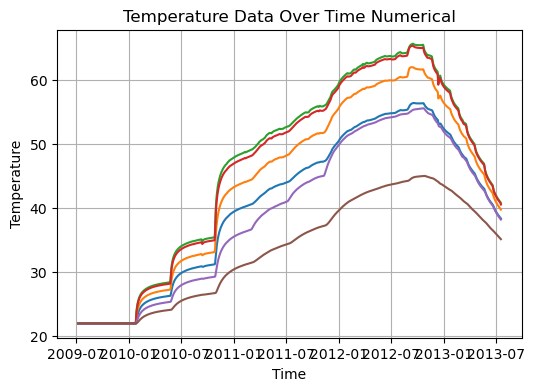

In [13]:
plt.figure(figsize=(6, 4))
for i in range(temperature_data.shape[0]):
    plt.plot(num_df['Time'], num_temperature_data[i, :], label=f'Temperature {i+1}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title('Temperature Data Over Time Numerical')
plt.grid(True)
plt.show()

In [15]:
experimanrtal_data_path = "../TED_Temperature.xlsx"
df = pd.read_excel(experimanrtal_data_path)
temperature_columns = df.columns[2:]
temperature_data = df[temperature_columns].T.values#[:2]
temperature_data_mask = ~np.isnan(temperature_data)
temperature_data_mask = temperature_data_mask.flatten()
time_points = df['Time'] # Sau dùng để visulization
print(f'temperature_data shape:{temperature_data.shape}')
print(f'temperature_data_mask shape:{temperature_data_mask.shape}')
print(df.head())

temperature_data shape:(6, 1473)
temperature_data_mask shape:(8838,)
        Time  STT  TED1210_TEM_05  TED1219_TEM_05  TED1250_TEM_01  \
0 2009-07-08    1             NaN             NaN             NaN   
1 2009-07-09    2             NaN             NaN             NaN   
2 2009-07-10    3             NaN             NaN             NaN   
3 2009-07-11    4             NaN             NaN             NaN   
4 2009-07-12    5             NaN             NaN             NaN   

   TED1251_TEM_01  TED1253_TEM_01  TED1258_TEM_01  
0             NaN       21.494342             NaN  
1       21.534905       21.491602             NaN  
2       21.539591       21.497382             NaN  
3       21.550029       21.504905             NaN  
4       21.561187       21.516124             NaN  


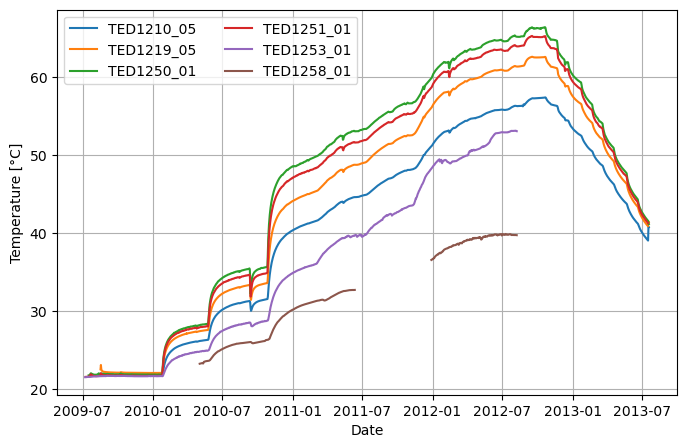

In [21]:
sensors = ["TED1210_05","TED1219_05","TED1250_01","TED1251_01","TED1253_01","TED1258_01"]
plt.figure(figsize=(8, 5))
for i in range(temperature_data.shape[0]):
    plt.plot(df['Time'], temperature_data[i, :], label=f'{sensors[i]}')
plt.xlabel('Date',fontsize=10)
plt.ylabel('Temperature [°C]',fontsize=10)
plt.legend(ncol=2, fontsize=10)
#plt.title('InsituTemperature Data Over Time')
plt.grid(True)
plt.show()

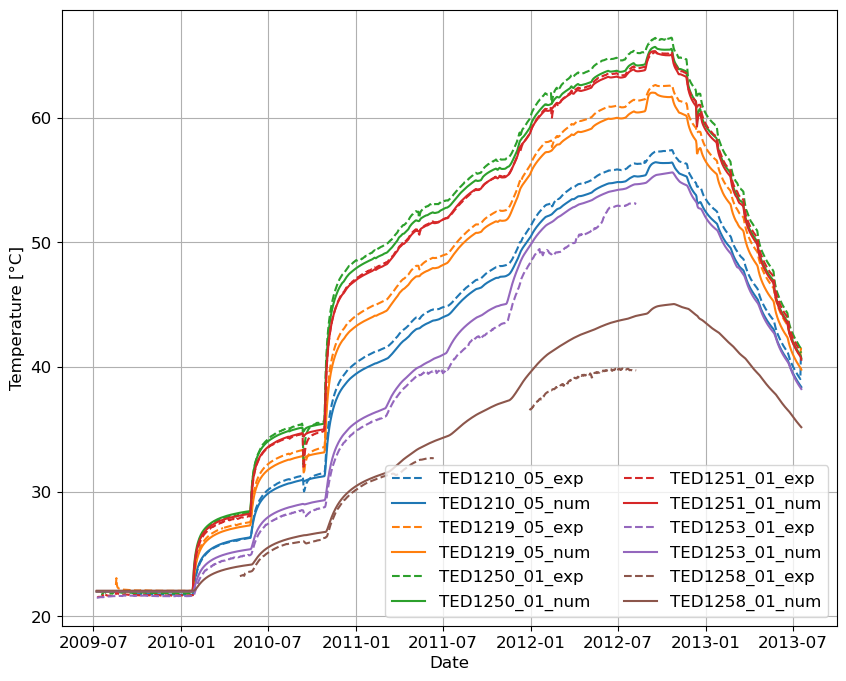

In [49]:
plt.figure(figsize=(10, 8))

# Lấy danh sách màu tự động (1 màu cho mỗi sensor)
colors = plt.cm.tab10.colors  # hoặc 'tab20', 'Set1', v.v.

for i, sensor in enumerate(sensors):
    color = colors[i % len(colors)]
    plt.plot(df['Time'], temperature_data[i, :], ls="--", color=color, label=f'{sensor}_exp' )
    plt.plot(df['Time'], num_temperature_data[i, :], ls="-", color=color, label=f'{sensor}_num')

plt.xlabel('Date',fontsize=12)
plt.ylabel('Temperature [°C]',fontsize=12)
plt.legend(ncol=2)
plt.grid(True)

plt.show()


In [11]:

noise_var = 1e-1
def Surrogate(point_list, params):
  model_path = './TED_fno1d_model.pth'
  params_tensor = torch.tensor(params, dtype=torch.float32)

  new_point_list = []
  for i in range(point_list.shape[0]):
      p = torch.tensor(point_list[i], dtype=torch.float32)
      combined = torch.cat([p, params_tensor], dim=0)  # (2,) + (4,) → (6,)
      new_point_list.append(combined)

  X_BI_test = torch.stack(new_point_list)  # shape (15, 6)

  X = X_BI_test.permute(1, 0).to(device)
  X[0:2,:] = X[0:2,:]/L
  #X[2:3,:] = standardize_tensor(X[2:3,:], 0.8, 2.5)
  #X[3:4,:] = standardize_tensor(X[3:4,:], 1.1, 2.5)
  X[4:5,:] = standardize_tensor(X[4:5,:], PS_MIN, PS_MAX)
  X[5:6,:] = standardize_tensor(X[5:6,:], CP_MIN, CP_MAX)
  y = predict_FW(model_path, X, device=device)#[:2946]
  y = y[temperature_data_mask]
  return y

def log_prior(z):
    z = np.asarray(z, dtype=float)
    if np.any(np.abs(z) > 5):
        return -np.inf
    # prior N(0,1) độc lập từng chiều (bỏ hằng số)
    return -0.5 * np.sum(z**2)

def log_likelihood(z):
    z = prior_mean + z * prior_std
    # ràng buộc vật lý (nếu thật sự làm việc ở không gian vật lý)
    if np.any(z < lower_bounds) or np.any(z > upper_bounds):
        return -np.inf

    u_pred = Surrogate(point_list, z)
    if u_pred is None:
        return -np.inf

    if isinstance(u_pred, torch.Tensor):
        u_pred = u_pred.detach().cpu().numpy()

    residual = u_obs - u_pred
    if not np.all(np.isfinite(residual)):
        return -np.inf

    N = residual.size
    ll = -0.5 * ( np.sum(residual**2) / noise_var + N * np.log(2.0 * np.pi * noise_var) )
    return float(ll)


def log_posterior(z):
    lp = log_prior(z)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(z)
    if not np.isfinite(ll):
        return -np.inf
    return float(lp + ll)


In [89]:
# ---------- Prior thông số vật lý (bạn đã khai báo ở cuối – giữ nguyên) ----------
PS_mean = (PS_MIN + PS_MAX) / 2
PS_std  = 40
CP_mean = (CP_MIN + CP_MAX) / 2
CP_std  = 70

prior_mean   = np.array([1.31, 1.5, PS_mean, CP_mean], dtype=float)
prior_std    = np.array([0.25, 0.25, PS_std,  CP_std ], dtype=float)
lower_bounds = np.array([0.8,  1.1,  PS_MIN,  CP_MIN], dtype=float)
upper_bounds = np.array([2.0,  2.5,  PS_MAX,  CP_MAX], dtype=float)


u_obs = temperature_data.flatten()[temperature_data_mask]


In [15]:
import time

n_phys_params = 4
n_params = n_phys_params    # +1 cho sigma_obs
n_walkers = 4 * n_params
n_steps =1_000

t_start = time.time()
initial_z = np.random.randn(n_walkers, n_params)  # z ~ N(0,1)
log_likelihood(initial_z[0])

-1554148.603172227

In [91]:
import time

n_phys_params = 4
n_params = n_phys_params    # +1 cho sigma_obs
n_walkers = 12 * n_params
n_steps = 5_000

t_start = time.time()
initial_z = np.random.randn(n_walkers, n_params)  # z ~ N(0,1)
sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior)
print("🔁 Running MCMC...")
sampler.run_mcmc(initial_z, n_steps, progress=True)
print("✅ Done.")
t_end = time.time()
print(f"Thời gian chạy: {t_end - t_start:.2f} giây")


🔁 Running MCMC...


 53%|█████████████████████████████████████████                                     | 2631/5000 [12:19<11:17,  3.50it/s]Traceback (most recent call last):
  File "C:\Users\hieu.pham-quang\AppData\Local\anaconda3\Lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hieu.pham-quang\AppData\Local\Temp\ipykernel_4100\3751344705.py", line 57, in log_posterior
    ll = log_likelihood(z)
         ^^^^^^^^^^^^^^^^^
  File "C:\Users\hieu.pham-quang\AppData\Local\Temp\ipykernel_4100\3751344705.py", line 37, in log_likelihood
    u_pred = Surrogate(point_list, z)
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hieu.pham-quang\AppData\Local\Temp\ipykernel_4100\3751344705.py", line 20, in Surrogate
    y = predict_FW(model_path, X, device=device)#[:2946]
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hieu.pham-quang\01.Theisse\Experimental\TED\code\FW_FNO1

emcee: Exception while calling your likelihood function:
  params: [ 0.09624226 -0.24221617 -0.10896859  0.83429293]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

Acceptance (per walker): [0.458 0.499 0.489 0.471 0.061 0.478 0.483 0.488 0.059 0.01  0.48  0.482
 0.05  0.48  0.486 0.493 0.48  0.49  0.491 0.48  0.053 0.003 0.48  0.493
 0.49  0.492 0.483 0.483 0.486 0.479 0.485 0.496 0.497 0.49  0.044 0.059
 0.497 0.484 0.499 0.483 0.482 0.492 0.494 0.465 0.485 0.477 0.471 0.486]
🧹 Số walker bị loại bỏ: 8 / 48
----- Posterior summary -----
Param θ1: Mean = 1.333927e+00,  SD = 5.053472e-04
Param θ2: Mean = 1.439475e+00,  SD = 9.775043e-04
Param θ3: Mean = 2.395564e+03,  SD = 9.976544e-02
Param θ4: Mean = 1.008203e+03,  SD = 2.609329e-01


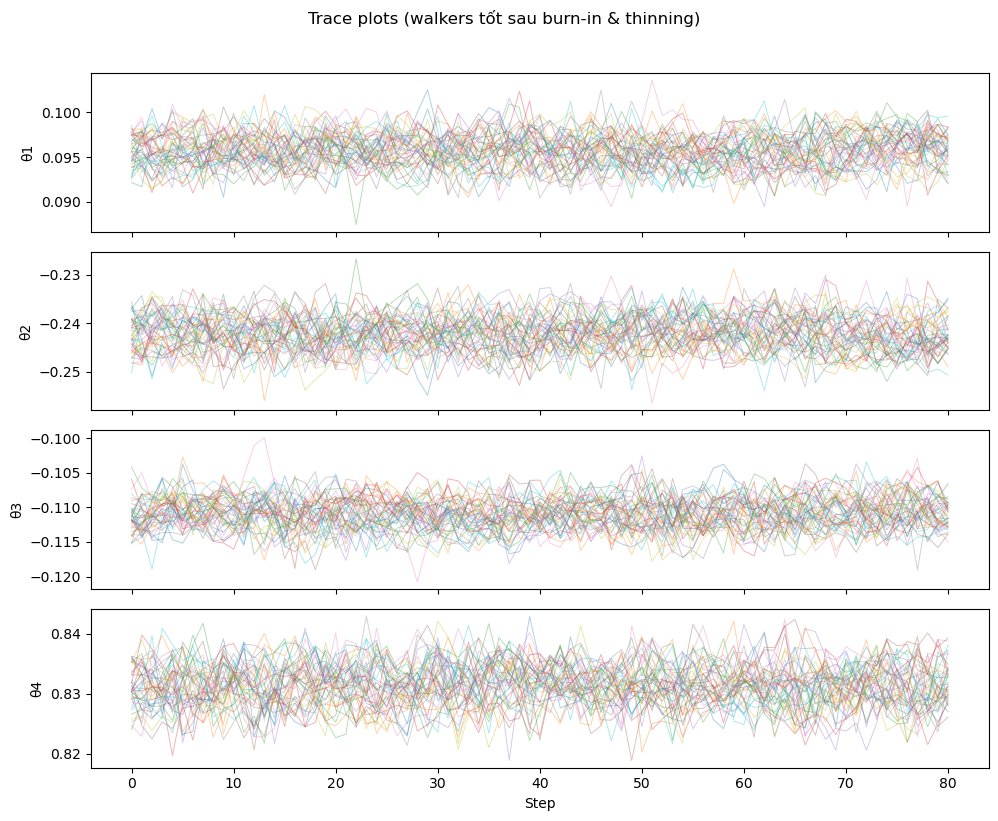

In [93]:
# ---------- Chẩn đoán nhanh ----------
acceptance_fraction = sampler.acceptance_fraction
print("Acceptance (per walker):", np.round(acceptance_fraction, 3))

threshold = 2e-1                      # loại walker gần như không chấp nhận
burn_in = 1000
thin_step = 20
good_walkers = np.where(acceptance_fraction >= threshold)[0]
bad_walkers  = np.where(acceptance_fraction <  threshold)[0]
print(f"🧹 Số walker bị loại bỏ: {len(bad_walkers)} / {n_walkers}")

# Lấy chuỗi sau burn-in + thinning, chỉ giữ walker tốt
chain_all = sampler.get_chain(discard=burn_in, thin=thin_step, flat=False)   # (steps, walkers, params)
chain_good = chain_all[:, good_walkers, :]                                   # (steps, good_walkers, params)

# ---------- Đưa về không gian tham số gốc để báo cáo ----------
samples_z = chain_good.reshape(-1, n_params)
z_phys  = samples_z


# 4 tham số vật lý
samples_params = z_phys * prior_std + prior_mean


# ---------- Thống kê hậu nghiệm ----------
mean_params = np.mean(samples_params, axis=0)
std_params  = np.std(samples_params, axis=0, ddof=1)


print("----- Posterior summary -----")
for i in range(n_phys_params):
    print(f"Param θ{i+1}: Mean = {mean_params[i]:.6e},  SD = {std_params[i]:.6e}")


# ---------- Trace plots ----------
param_names = [f"θ{i+1}" for i in range(n_phys_params)]
fig, axes = plt.subplots(n_params, figsize=(10, 2.0 * n_params), sharex=True)
for j in range(n_params):
    for w in range(chain_good.shape[1]):
        axes[j].plot(chain_good[:, w, j], alpha=0.35, lw=0.7)
    axes[j].set_ylabel(param_names[j])
axes[-1].set_xlabel("Step")
plt.suptitle("Trace plots (walkers tốt sau burn-in & thinning)", y=1.02)
plt.tight_layout()
plt.show()

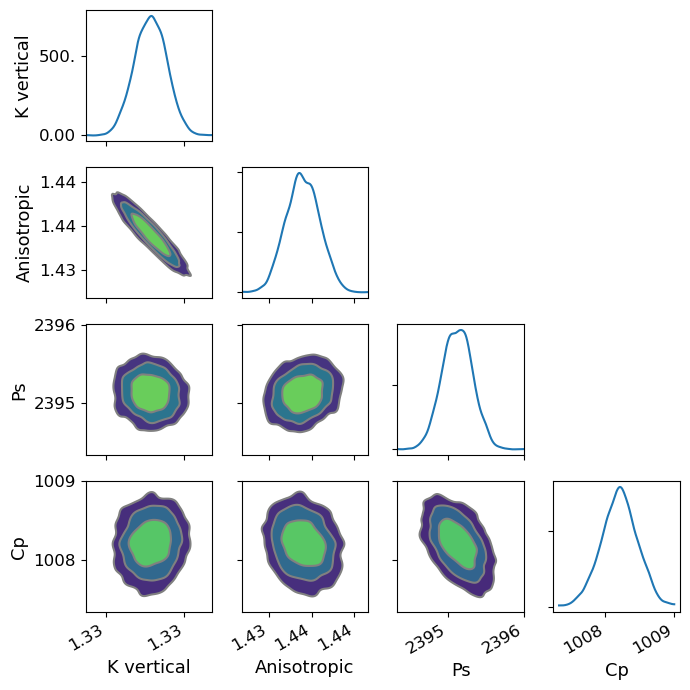

In [127]:
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Hàm định dạng chỉ lấy tối đa 4 ký tự
def short_fmt(x, pos):
    s = f"{x:.6f}"  # format có phần thập phân đủ để cắt
    return s[:4]    # chỉ lấy 4 ký tự đầu tiên
    
param_names_real = ["K vertical", "Anisotropic", "Ps", "Cp"]

posterior_params_dict = {param_names_real[i]: samples_params[:, i].reshape(1, -1) for i in range(samples_params.shape[1])}

idata_params = az.from_dict(
    posterior=posterior_params_dict,
    coords={"chain": [0], "draw": np.arange(samples_params.shape[0])},
    dims={"K vertical": [], "Anisotropic": [], "Density(Ps)": [], "Heat capacity(Cp)": []}
)

# Plot pairwise distributions using plot_pair
az.plot_pair(idata_params, kind='kde', marginals=True, textsize=12,figsize=(7, 7))
axes = plt.gcf().axes
for ax in axes:
    ax.xaxis.set_major_formatter(FuncFormatter(short_fmt))
    ax.yaxis.set_major_formatter(FuncFormatter(short_fmt))
    ax.tick_params(axis='both', labelsize=12)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_horizontalalignment('right')
#plt.suptitle("Pairwise Histograms of Posterior Samples", y=0.8)
plt.tight_layout()
plt.show()

In [99]:
sensor_slices = []
current_masked_index = 0
# Reshape the mask to match the original temperature_data shape (num_sensors, num_time_points)
temperature_data_mask_reshaped = temperature_data_mask.reshape(temperature_data.shape)

for i in range(temperature_data_mask_reshaped.shape[0]):
    # Count the number of True values for the current sensor in the mask
    num_masked_points_for_sensor = np.sum(temperature_data_mask_reshaped[i, :])

    # Define the slice for the current sensor in the flattened masked data (u_obs)
    start_index = current_masked_index
    end_index = current_masked_index + num_masked_points_for_sensor
    sensor_slices.append(slice(start_index, end_index))

    # Update the current index for the next sensor
    current_masked_index = end_index



In [101]:

# 1) Dự báo surrogate cho từng mẫu và ghép sigma_eff tương ứng
pred_list = []
sigma_eff_list = []
keep_count = 0

S_total = samples_params.shape[0]
print(f"Generating posterior predictive for {S_total} posterior samples...")

for i, (params) in enumerate(samples_params):
    # bỏ mẫu ngoài bounds để tránh lỗi surrogate
    if np.any(params < lower_bounds) or np.any(params > upper_bounds):
        continue

    pred = Surrogate(point_list, params)
    if pred is None:
        continue
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()

    # kiểm tra shape
    if pred.shape != u_obs.shape:
        continue

    pred_list.append(pred)
    keep_count += 1

    if (i+1) % 1000 == 0:
        print(f"  processed {i+1}/{S_total} samples...")

if keep_count == 0:
    raise RuntimeError("Không có mẫu hợp lệ để tính PPI (kiểm tra bounds/shape).")

pred_array = np.stack(pred_list, axis=0)                 # (S_keep, N)
print("Shapes:", pred_array.shape)

Generating posterior predictive for 3240 posterior samples...
  processed 1000/3240 samples...
  processed 2000/3240 samples...
  processed 3000/3240 samples...
Shapes: (3240, 7518)


In [103]:
# 2) Sinh posterior predictive y_rep = pred + noise, noise ~ N(0, sigma_eff^2)

noise = np.random.normal(loc=0.0, scale=math.sqrt(noise_var), size=pred_array.shape)
y_rep = pred_array + noise                                # (S_keep, N)

# 3) Tính PPI 95% theo trục mẫu
ppi_low  = np.quantile(y_rep, 0.025, axis=0)              # (N,)
ppi_high = np.quantile(y_rep, 0.975, axis=0)              # (N,)

# Tính mean của dự báo "không noise" để vẽ
mean_pred = pred_array.mean(axis=0)

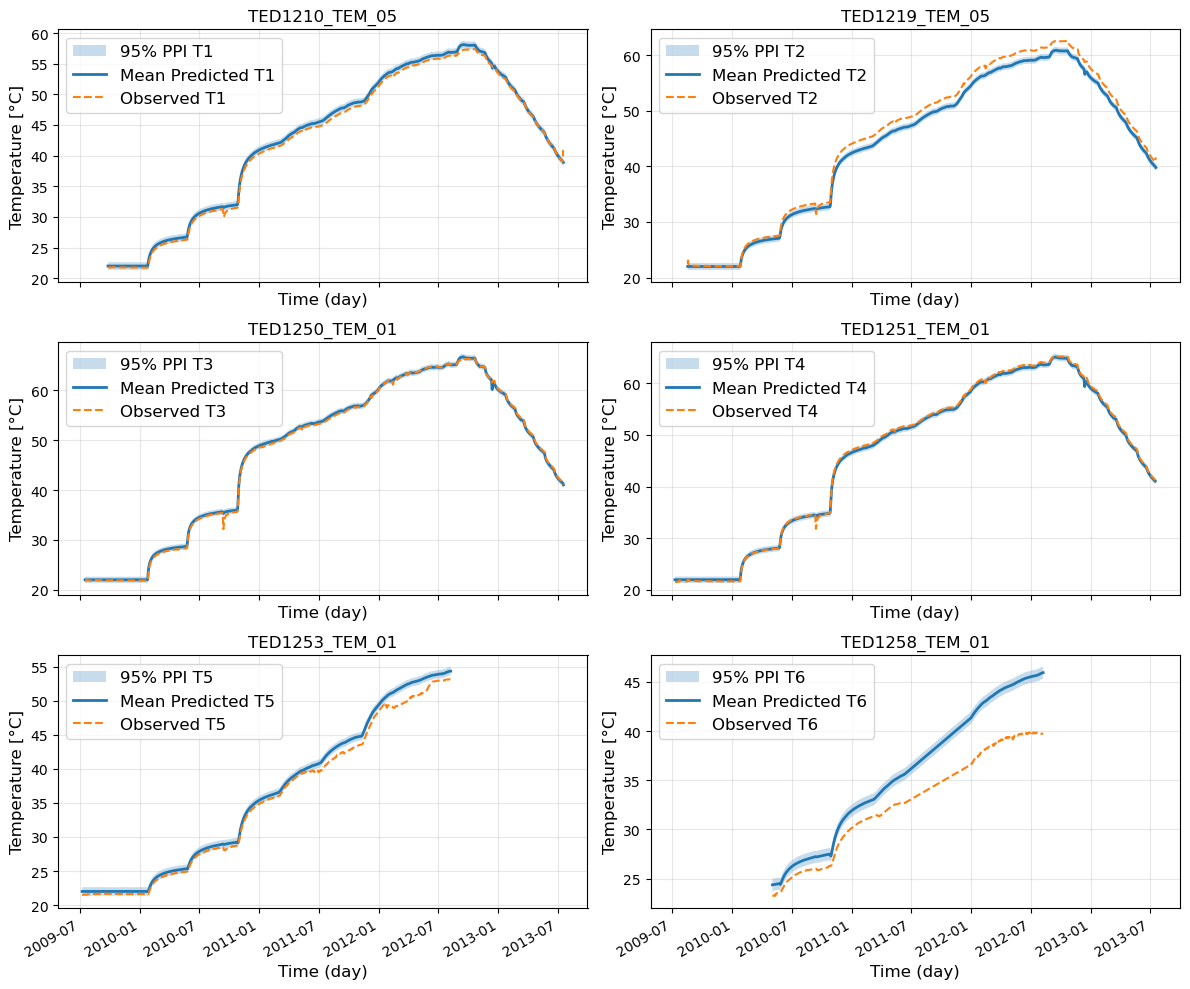

Coverage T1: 72.9%
Coverage T2: 20.6%
Coverage T3: 98.4%
Coverage T4: 98.8%
Coverage T5: 59.8%
Coverage T6: 0.0%


In [129]:

labels = [f"T{i+1}" for i in range(6)]

# Create the plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()
for k, slc in enumerate(sensor_slices):
    ax = axes[k]
    obs_k  = u_obs[slc]
    mean_k = mean_pred[slc]
    low_k  = ppi_low[slc]
    high_k = ppi_high[slc]
    # Use the corresponding time points for this sensor's data
    t_k    = time_points[temperature_data_mask.reshape(temperature_data.shape)[k, :]]


    # dải PPI
    ax.fill_between(t_k, low_k, high_k, alpha=0.25, label=f"95% PPI {labels[k]}")
    # mean
    ax.plot(t_k, mean_k, lw=2, label=f"Mean Predicted {labels[k]}")
    # observed
    ax.plot(t_k, obs_k, ls="--", lw=1.5, label=f"Observed {labels[k]}")

    ax.set_title(f"{sensors[k]}")
    ax.set_xlabel("Time (day)",fontsize=12)
    ax.set_ylabel("Temperature [°C]",fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=1, fontsize=12)

    for label in ax.get_xticklabels():
            label.set_rotation(30)
            label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

# Coverage theo từng cảm biến (tùy chọn)
for k, slc in enumerate(sensor_slices):
    cover_k = np.mean((u_obs[slc] >= ppi_low[slc]) & (u_obs[slc] <= ppi_high[slc]))
    print(f"Coverage {labels[k]}: {cover_k*100:.1f}%")

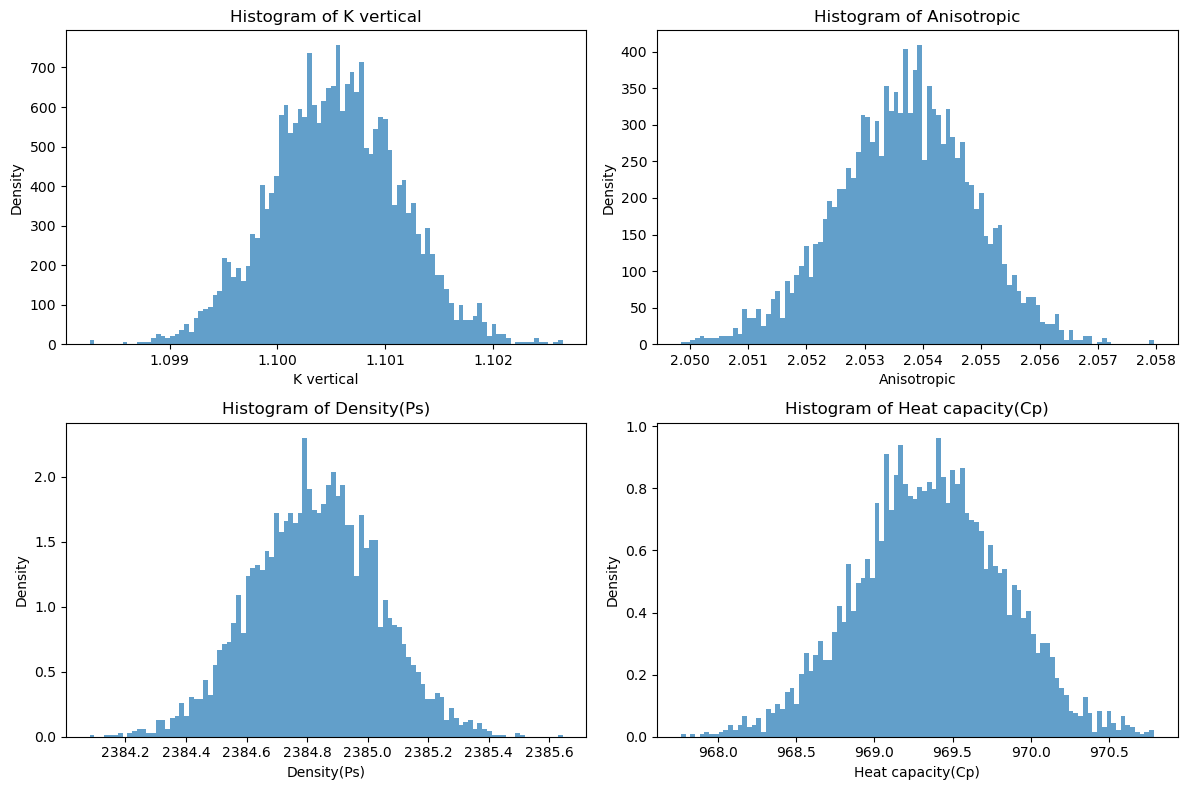

In [41]:
param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"] # Assuming 4 parameters

plt.figure(figsize=(12, 8))
for i in range(samples_params.shape[1]):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    plt.hist(samples_params[:, i], bins=100, density=True, alpha=0.7)
    plt.xlabel(param_names_real[i])
    plt.ylabel("Density")
    plt.title(f"Histogram of {param_names_real[i]}")

plt.tight_layout()
plt.show()

In [241]:
# ---------- tiện ích ----------
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def split_chains(samples_3d, split=True):
    # samples_3d: (n_walkers, n_steps, n_dim)
    w, s, d = samples_3d.shape
    if split:
        # Ensure both halves have the same number of steps
        split_point = s // 2
        first = samples_3d[:, :split_point, :]
        second = samples_3d[:, split_point:split_point*2, :] # Adjust slicing here
        return np.concatenate([first, second], axis=0)
    return samples_3d

def compute_rhat(samples_3d):
    # Split R-hat (Gelman–Rubin)
    chains = split_chains(samples_3d, split=True)
    m, n, d = chains.shape
    # Handle cases where chains are empty or have insufficient steps
    if m == 0 or n < 2:
        return np.full(d, np.nan)
    means = chains.mean(axis=1)               # (m,d)
    variances = chains.var(axis=1, ddof=1)    # (m,d)
    # Handle cases where variance is zero or NaN
    B = n * np.var(means, axis=0, ddof=1)     # (d,)
    W = np.mean(variances, axis=0)            # (d,)
    # Avoid division by zero or NaN
    var_hat = (n-1)/n * W + B/n
    Rhat = np.sqrt(np.divide(var_hat, W, out=np.full_like(var_hat, np.nan), where=W!=0))
    return Rhat


def integrated_autocorr_time_param(x, max_lag=None):
    # Ước lượng tau_int qua FFT + initial positive sequence
    # Add checks for empty or short input
    x = np.asarray(x) - np.mean(x)
    n = x.size
    if n <= 1:
        return np.nan
    if max_lag is None:
        max_lag = min(1000, n//2)
    # Use a more stable method for FFT size calculation
    fft_size = 2**int(np.ceil(np.log2(max(2*n, 2)))) # Ensure at least 2 for log2
    if fft_size > 2**31 - 1: # Check for potential overflow before casting to int
        return np.nan # Or handle error appropriately
    try:
        f = np.fft.rfft(x, n=fft_size)
        acf = np.fft.irfft(f * np.conjugate(f))[:n]
        # Handle case where acf[0] is zero or NaN
        if acf[0] == 0 or np.isnan(acf[0]):
            return np.nan
        acf /= acf[0]
        ssum = 1.0
        for k in range(1, max_lag):
            if acf[k] <= 0:
                break
            ssum += 2.0 * acf[k]
        return max(ssum, 1.0)
    except Exception:
        return np.nan # Handle potential errors during FFT or ACF calculation


def compute_ess(samples_3d):
    # ESS ≈ (n_walkers * n_steps) / tau_int (per-parameter)
    # Calculate ESS for each parameter based on the integrated autocorrelation time
    w, s, d = samples_3d.shape
    total_steps = w * s
    ess = np.zeros(d)
    for j in range(d):
        # Calculate autocorrelation time for each walker and average
        tau_per_walker = []
        for i in range(w):
            tau = integrated_autocorr_time_param(samples_3d[i, :, j])
            if not np.isnan(tau):
                tau_per_walker.append(tau)

        if tau_per_walker:
             # Use the mean of autocorrelation times across walkers
            mean_tau = np.mean(tau_per_walker)
            if mean_tau > 0:
                 ess[j] = total_steps / mean_tau
            else:
                ess[j] = np.nan # Handle zero mean tau
        else:
            ess[j] = np.nan # Handle no valid tau estimates

    return ess

def summarize_param(samples, names=None, quantiles=(0.05, 0.5, 0.95)):
    qs = np.quantile(samples, quantiles, axis=0).T
    means = samples.mean(axis=0)
    sds = samples.std(axis=0, ddof=1)
    out = []
    for j in range(samples.shape[1]):
        out.append({
            "name": names[j] if names else f"param_{j+1}",
            "mean": float(means[j]),
            "sd": float(sds[j]),
            f"q{int(quantiles[0]*100)}": float(qs[j,0]),
            f"q{int(quantiles[1]*100)}": float(qs[j,1]),
            f"q{int(quantiles[2]*100)}": float(qs[j,2]),
        })
    return out

def save_traceplots(samples_3d, out_dir, names=None):
    w, s, d = samples_3d.shape
    for j in range(d):
        plt.figure(figsize=(8,3))
        for i in range(w):
            plt.plot(np.arange(s), samples_3d[i,:,j], linewidth=0.6)
        plt.xlabel("Step"); plt.ylabel(names[j] if names else f"param_{j+1}")
        plt.title(f"Trace: {names[j] if names else f'param_{j+1}'}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"trace_{j+1}.png"), dpi=150)
        plt.close()

def save_density_plots(samples_2d, out_dir, names=None, bins=60):
    n, d = samples_2d.shape
    for j in range(d):
        plt.figure(figsize=(5,3.5))
        plt.hist(samples_2d[:,j], bins=bins, density=True, alpha=0.7)
        plt.xlabel(names[j] if names else f"param_{j+1}")
        plt.ylabel("Density")
        plt.title(f"Posterior density: {names[j] if names else f'param_{j+1}'}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"density_{j+1}.png"), dpi=150)
        plt.close()

def save_pair_scatter(samples_2d, out_dir, names=None, max_pairs=6):
    n, d = samples_2d.shape
    cnt = 0
    for i in range(d):
        for j in range(i+1, d):
            plt.figure(figsize=(4,4))
            plt.plot(samples_2d[:,i], samples_2d[:,j],
                     linestyle='none', marker='.', markersize=1.5, alpha=0.4)
            plt.xlabel(names[i] if names else f"param_{i+1}")
            plt.ylabel(names[j] if names else f"param_{j+1}")
            plt.title("Pairwise scatter")
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"pair_{i+1}_{j+1}.png"), dpi=150)
            plt.close()
            cnt += 1
            if cnt >= max_pairs:
                return

def make_emcee_report(sampler, burn=0, names=None, out_dir="./emcee_report_FNO"):
    """
    Tạo báo cáo chẩn đoán từ emcee.EnsembleSampler đã chạy.
    """
    ensure_dir(out_dir); fig_dir = ensure_dir(os.path.join(out_dir, "figs"))

    acceptance_fraction = sampler.acceptance_fraction
    threshold = 1e-1
    good_walkers = np.where(acceptance_fraction >= threshold)[0]
    bad_walkers  = np.where(acceptance_fraction < threshold)[0]
    print(f"🧹 Số walker bị loại bỏ: {len(bad_walkers)} / {n_walkers}")

    # Ensure burn and thin are applied correctly before getting the chain
    chain_b = sampler.get_chain(discard=burn, thin=1, flat=False)[:, good_walkers, :] # Keep original thin step for later flattening
    # Apply additional thinning if needed for analysis, but the code already has thin_step=10
    # So using thin=1 here and then reshaping with the overall thin_step should be correct.
    # Or adjust the discard and thin in get_chain call based on desired post-processing.
    # Given the original code used thin_step=10, let's keep that logic.
    chain_analyzed = sampler.get_chain(discard=burn_in, thin=thin_step, flat=False)[:, good_walkers, :]

    logp  = sampler.get_log_prob()   # (nsteps, nwalkers)

    samples_3d = np.transpose(chain_analyzed, (1,0,2))  # (w,s,d) - use chain_analyzed for diagnostics
    w, s, d = samples_3d.shape
    samples_2d = samples_3d.reshape(w*s, d)
    # Update names to match the shape of samples_2d
    if names is None or len(names) != d:
        names = [f"theta_{j+1}" for j in range(d)]

    # Diagnostics
    acc_frac = sampler.acceptance_fraction
    try:
        # Use emcee's built-in autocorrelation time estimation
        tau_emcee = sampler.get_autocorr_time(discard=burn, thin=thin_step, quiet=True).tolist()
    except Exception:
        tau_emcee = None
    # Compute ESS based on the estimated autocorrelation time (either emcee's or custom)
    if tau_emcee:
        ess = [(w * s) / t if t > 0 else np.nan for t in tau_emcee]
    else:
        # Fallback to custom ESS calculation if emcee's fails
        ess = compute_ess(samples_3d).tolist()

    rhat = compute_rhat(samples_3d).tolist()
    summary = summarize_param(samples_2d, names=names)

    # Figures
    save_traceplots(samples_3d, fig_dir, names)
    save_density_plots(samples_2d, fig_dir, names)
    save_pair_scatter(samples_2d, fig_dir, names)

    # Report
    report_path = os.path.join(out_dir, "report.md")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write("# Báo cáo chẩn đoán MCMC (emcee)\n\n")
        f.write(f"- Số walker: {sampler.nwalkers}\n")
        f.write(f"- Số bước: {sampler.iteration} (burn-in: {burn})\n\n")

        f.write("## Acceptance fraction\n")
        f.write(f"- mean: {np.mean(acc_frac):.3f}\n")
        f.write(f"- per-walker: {np.array2string(acc_frac, precision=3)}\n\n")

        f.write("## R-hat (split)\n")
        # Handle potential NaN values in R-hat output
        rhat_str = np.array2string(np.array(rhat), precision=3, separator=', ', suppress_small=True)
        f.write(f"- {rhat_str}\n\n")
        f.write("**Gợi ý:** R-hat gần 1 (≤ 1.01–1.05) là tốt.\n\n")

        f.write("## ESS (Effective Sample Size)\n")
        # Handle potential NaN values in ESS output
        ess_str = np.array2string(np.array(ess), precision=3, separator=', ', suppress_small=True)
        f.write(f"- {ess_str}\n\n")

        f.write("## Integrated autocorrelation time (emcee)\n")
        if tau_emcee is None:
            f.write("- Không tính được (chuỗi ngắn) hoặc không ổn định.\n\n")
        else:
            # Handle potential NaN values in tau_emcee output
            tau_emcee_str = np.array2string(np.array(tau_emcee), precision=3, separator=', ', suppress_small=True)
            f.write(f"- tau ≈ {tau_emcee_str}\n\n")

        f.write("## Posterior summary\n")
        f.write("| Param | Mean | SD | q5% | q50% | q95% |\n|---|---:|---:|---:|---:|---:|\n")
        for row in summary:
            f.write(f"| {row['name']} | {row['mean']:.3f} | {row['sd']:.3f} | "
                    f"{row['q5']:.3f} | {row['q50']:.3f} | {row['q95']:.3f} |\n")
        f.write("\n")
        for j in range(d):
            f.write(f"### Trace: {names[j]}\n![trace](figs/trace_{j+1}.png)\n\n")
            f.write(f"### Density: {names[j]}\n![density](figs/density_{j+1}.png)\n\n")
        f.write("### Một số scatter pairwise\n")
        for fn in sorted(os.listdir(fig_dir)):
            if fn.startswith("pair_"):
                f.write(f"![pair](figs/{fn})\n")
    return report_path

# Fix: Provide the correct number of names (5) matching the dimensions of the samples
# Also, burn should match the discard in get_chain calls used for diagnostics
# Corrected names to match the 4 parameters in samples_params
path = make_emcee_report(sampler, burn=3500, names=param_names_real, out_dir="./emcee_report_FNO")
print("Report saved at:", path)

🧹 Số walker bị loại bỏ: 11 / 48
Report saved at: ./emcee_report_FNO\report.md


 log_sigma_obs | skew=0.02  kurt=-0.03  K2 p=0.584  Shapiro p=0.499  median=0.00211  HDI94=[-0.00224, 0.0065]
        theta1 | skew=-0.00  kurt=0.01  K2 p=0.929  Shapiro p=0.422  median=0.786  HDI94=[0.781, 0.791]
        theta2 | skew=-0.01  kurt=0.02  K2 p=0.791  Shapiro p=0.998  median=-0.185  HDI94=[-0.19, -0.18]
        theta3 | skew=-0.05  kurt=-0.04  K2 p=0.0674  Shapiro p=0.0279  median=0.625  HDI94=[0.597, 0.653]


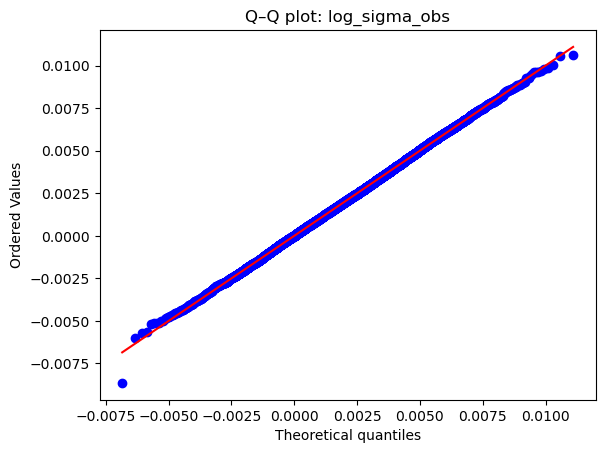

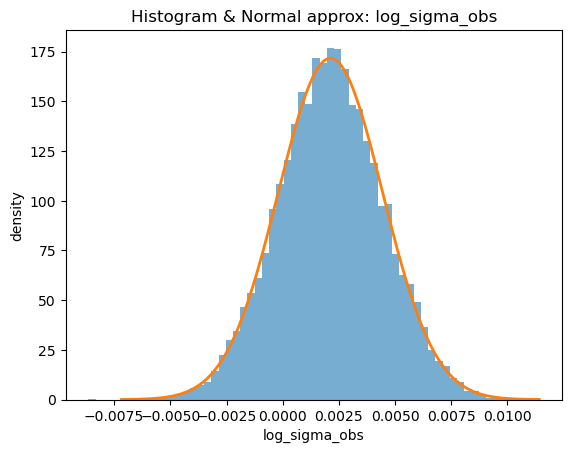

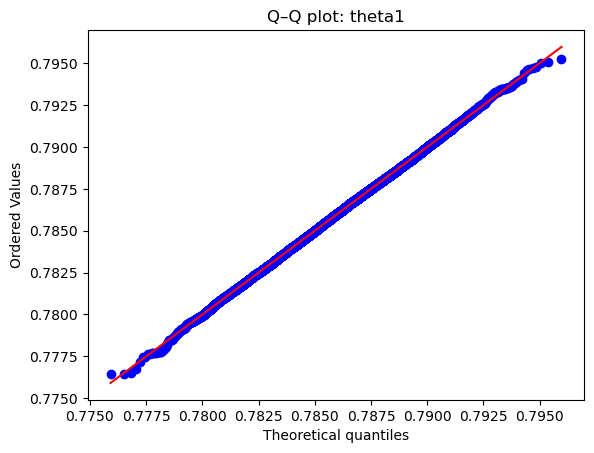

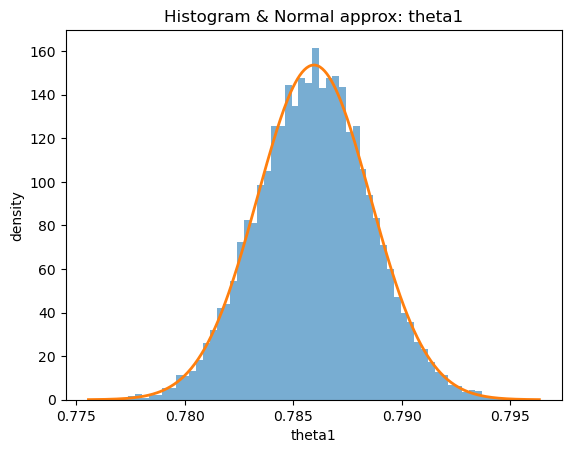

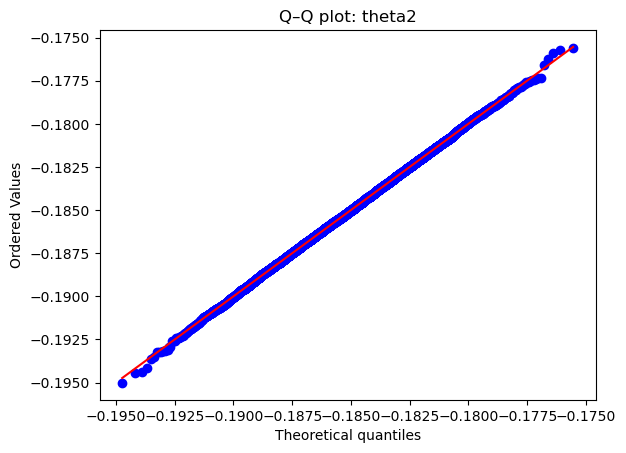

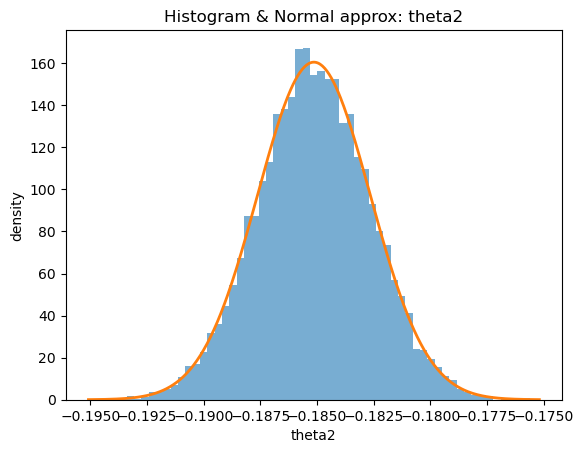

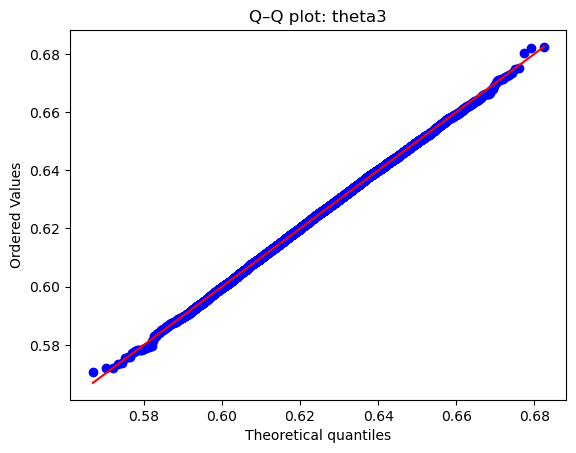

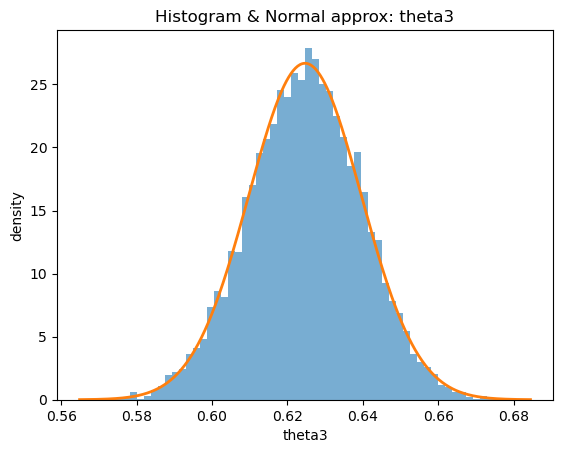

In [245]:
from scipy import stats
# Nếu bạn có chain dạng (n_steps, n_walkers, n_dim)
def flatten_chain(chain, discard=0, thin=1, walkers=None):
    # chọn walkers tốt nếu cần
    if walkers is not None:
        chain = chain[:, walkers, :]
    chain = chain[discard::thin]           # áp dụng discard/thin thêm (nếu muốn)
    n_steps, n_walkers, n_dim = chain.shape
    flat = chain.reshape(n_steps*n_walkers, n_dim)
    return flat  # (n_samples, n_dim)

def hdi(samples, alpha=0.06):  # 94% HDI mặc định (alpha=0.06)
    s = np.sort(samples)
    n = len(s)
    gap = int(np.floor((1 - alpha) * n))
    idx = np.argmin(s[gap:] - s[:n - gap])
    return s[idx], s[idx + gap]
def normality_report(samples_2d, names=None):
    """
    samples_2d: (n_samples, n_dim)
    """
    n_dim = samples_2d.shape[1]
    if names is None:
        names = [f"theta{i+1}" for i in range(n_dim)]

    rows = []
    for j in range(n_dim):
        x = samples_2d[:, j]
        mean = np.mean(x)
        std = np.std(x, ddof=1)
        med = np.median(x)
        lo, hi = hdi(x, alpha=0.06)  # 94% HDI
        skew = stats.skew(x, bias=False)
        kurt = stats.kurtosis(x, fisher=True, bias=False)  # 0 nếu normal
        # D'Agostino K^2 test (tốt cho sample lớn)
        k2_stat, k2_p = stats.normaltest(x)  # H0: normal
        # Shapiro (hiệu quả với mẫu nhỏ, nhưng có thể rất nhạy với mẫu lớn)
        sh_stat, sh_p = stats.shapiro(x[np.random.choice(len(x), size=min(5000, len(x)), replace=False)])
        rows.append({
            "name": names[j], "mean": mean, "std": std, "median": med,
            "HDI94_low": lo, "HDI94_high": hi,
            "skew": skew, "kurtosis_fisher": kurt,
            "normaltest_K2_p": k2_p, "shapiro_p": sh_p
        })
    return rows
def normality_report(samples_2d, names=None):
    """
    samples_2d: (n_samples, n_dim)
    """
    n_dim = samples_2d.shape[1]
    if names is None:
        names = [f"theta{i+1}" for i in range(n_dim)]

    rows = []
    for j in range(n_dim):
        x = samples_2d[:, j]
        mean = np.mean(x)
        std = np.std(x, ddof=1)
        med = np.median(x)
        lo, hi = hdi(x, alpha=0.06)  # 94% HDI
        skew = stats.skew(x, bias=False)
        kurt = stats.kurtosis(x, fisher=True, bias=False)  # 0 nếu normal
        # D'Agostino K^2 test (tốt cho sample lớn)
        k2_stat, k2_p = stats.normaltest(x)  # H0: normal
        # Shapiro (hiệu quả với mẫu nhỏ, nhưng có thể rất nhạy với mẫu lớn)
        sh_stat, sh_p = stats.shapiro(x[np.random.choice(len(x), size=min(5000, len(x)), replace=False)])
        rows.append({
            "name": names[j], "mean": mean, "std": std, "median": med,
            "HDI94_low": lo, "HDI94_high": hi,
            "skew": skew, "kurtosis_fisher": kurt,
            "normaltest_K2_p": k2_p, "shapiro_p": sh_p
        })
    return rows
def qq_and_hist_plots(samples_2d, names=None, bins=60):
    n_dim = samples_2d.shape[1]
    if names is None:
        names = [f"theta{i+1}" for i in range(n_dim)]
    for j in range(n_dim):
        x = samples_2d[:, j]
        mu, sd = np.mean(x), np.std(x, ddof=1)

        # Q-Q plot
        plt.figure()
        stats.probplot(x, dist="norm", sparams=(mu, sd), plot=plt)
        plt.title(f"Q–Q plot: {names[j]}")
        plt.show()

        # Histogram + Normal approx PDF
        plt.figure()
        _, _, _ = plt.hist(x, bins=bins, density=True, alpha=0.6)
        xs = np.linspace(mu - 4*sd, mu + 4*sd, 400)
        plt.plot(xs, stats.norm.pdf(xs, loc=mu, scale=sd), linewidth=2)  # không set màu cụ thể
        plt.title(f"Histogram & Normal approx: {names[j]}")
        plt.xlabel(names[j]); plt.ylabel("density")
        plt.show()
# Giả sử bạn đã có chain_good: (n_steps, n_walkers, n_dim)
flat = flatten_chain(chain_good)  # hoặc truyền walkers/thin riêng nếu cần
names = ["log_sigma_obs", "theta1", "theta2", "theta3", "theta4"]  # đặt theo thứ tự cột của bạn

report = normality_report(flat, names)
for r in report:
    print(
        f"{r['name']:>14} | skew={r['skew']:.2f}  kurt={r['kurtosis_fisher']:.2f}  "
        f"K2 p={r['normaltest_K2_p']:.3g}  Shapiro p={r['shapiro_p']:.3g}  "
        f"median={r['median']:.3g}  HDI94=[{r['HDI94_low']:.3g}, {r['HDI94_high']:.3g}]"
    )

qq_and_hist_plots(flat, names)
